<a href="https://colab.research.google.com/github/G-Gakii/ACH/blob/main/Medical_cost_prediction_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [95]:
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import SGDRegressor
import pandas as pd
import numpy as np
from sklearn.metrics import root_mean_squared_error
from sklearn.preprocessing import OneHotEncoder

from sklearn.preprocessing import StandardScaler
import seaborn as sns

In [2]:
medical_df =pd.read_csv("/content/acme_insurance.csv")

In [3]:
medical_df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
non_smoker_df =medical_df[medical_df['smoker'] =="no"]

In [5]:
non_smoker_df

,age,sex,bmi,children,smoker,region,charges
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
5,31,female,25.740,0,no,southeast,3756.62160
...,...,...,...,...,...,...,...
1332,52,female,44.700,3,no,southwest,11411.68500
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350


Create model

In [6]:
linear_model = LinearRegression()

In [7]:
inputs = non_smoker_df[['age']]

In [8]:
inputs

,age
1,18
2,28
3,33
4,32
5,31
...,...
1332,52
1333,50
1334,18
1335,18


In [9]:
target =non_smoker_df["charges"]

In [10]:
target

,charges
1,1725.55230
2,4449.46200
3,21984.47061
4,3866.85520
5,3756.62160
...,...
1332,11411.68500
1333,10600.54830
1334,2205.98080
1335,1629.83350


Train the model

In [11]:
linear_model.fit(inputs,target)

LinearRegression()

predict

In [12]:
linear_model.predict(np.array([[23],[62],[47]]))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([ 4055.30443855, 14478.01203897, 10469.2783465 ])

In [13]:
predictions =linear_model.predict(inputs)

In [14]:
root_mean_squared_error(target,predictions )

4662.505766636395

in sklearn
1. w(weight) is stored in model.coef_

2. b(bias) is stored in model.intercept


In [15]:
linear_model.coef_

array([267.24891283])

In [16]:
linear_model.intercept_

np.float64(-2091.4205565650864)

<Axes: xlabel='age', ylabel='charges'>

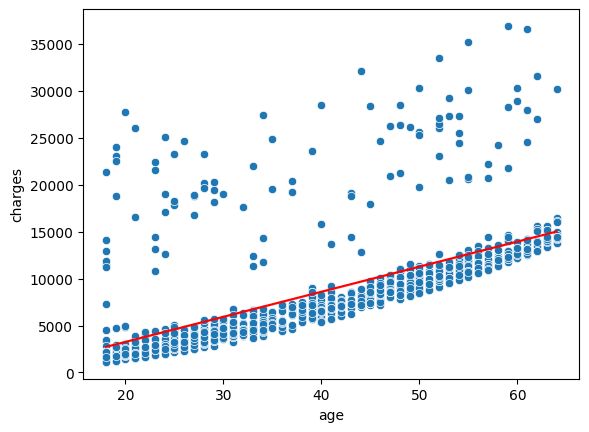

In [17]:
sns.scatterplot(x=inputs['age'],y=target)

sns.lineplot(x=inputs['age'],y=predictions,color="red")

Using SDGregressor

In [18]:
sgd_model = SGDRegressor()

In [19]:
sgd_model.fit(inputs,target)

SGDRegressor()

In [20]:
predictions=sgd_model.predict(inputs)

In [21]:
root_mean_squared_error(target,predictions)

4857.415228274172

<Axes: xlabel='age', ylabel='charges'>

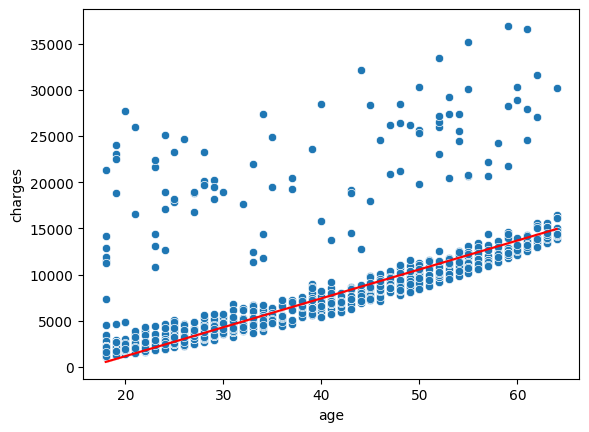

In [22]:
sns.scatterplot(x=inputs['age'],y=target)

sns.lineplot(x=inputs['age'],y=predictions,color="red")

In [23]:
smokers =medical_df[medical_df['smoker'] == "yes"]

In [24]:
smokers

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
11,62,female,26.290,0,yes,southeast,27808.72510
14,27,male,42.130,0,yes,southeast,39611.75770
19,30,male,35.300,0,yes,southwest,36837.46700
23,34,female,31.920,1,yes,northeast,37701.87680
...,...,...,...,...,...,...,...
1313,19,female,34.700,2,yes,southwest,36397.57600
1314,30,female,23.655,3,yes,northwest,18765.87545
1321,62,male,26.695,0,yes,northeast,28101.33305
1323,42,female,40.370,2,yes,southeast,43896.37630


In [25]:
x =smokers[["age"]]

In [26]:
y=smokers["charges"]

In [27]:
linear_model.fit(x,y)

LinearRegression()

In [28]:
prediction =linear_model.predict(x)

In [29]:
root_mean_squared_error(y,prediction)

10711.00334810241

<Axes: xlabel='age', ylabel='charges'>

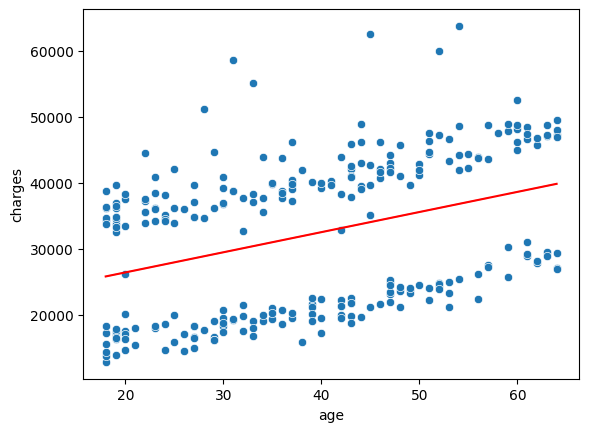

In [30]:
sns.scatterplot(x=x['age'],y=y)
sns.lineplot(x=x['age'],y=prediction,color="red")

In [31]:
sgd_model.fit(x,y)

SGDRegressor()

In [32]:
predict_sgd=sgd_model.predict(x)

In [33]:
root_mean_squared_error(y,predict_sgd)

9046937954.737368

<Axes: xlabel='age', ylabel='charges'>

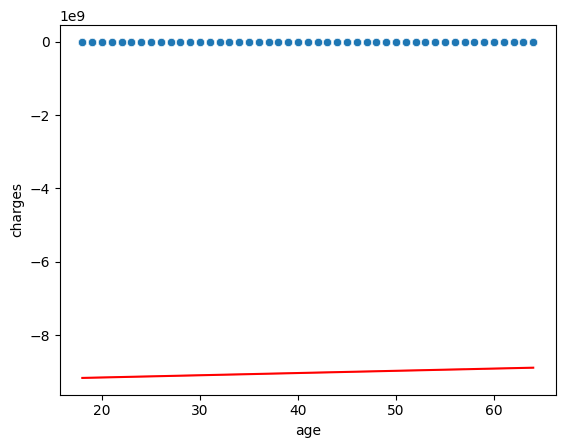

In [34]:
sns.scatterplot(x=x['age'],y=y)
sns.lineplot(x=x['age'],y=predict_sgd,color="red")

# Linear regression with multiple features

In [36]:
features =["age","bmi"]


In [37]:
x=non_smoker_df[features]
y=non_smoker_df["charges"]

In [38]:
model = LinearRegression()

In [39]:
model.fit(x,y)

LinearRegression()

In [41]:
predictions = model.predict(x)

In [42]:
root_mean_squared_error(y,predictions)

4662.3128354612945

<Axes: xlabel='bmi', ylabel='charges'>

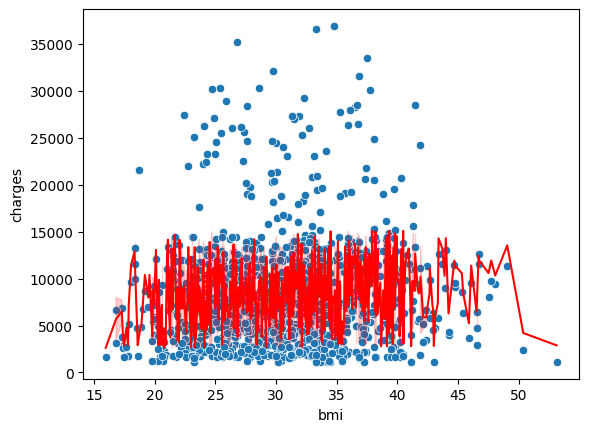

In [47]:
sns.scatterplot(x=x['bmi'],y=y)
sns.lineplot(x=x['bmi'],y=predictions,color="red"
             )

In [48]:
non_smoker_df.charges.corr(non_smoker_df.children)

np.float64(0.13892870453542192)

In [49]:
medical_df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


<Axes: xlabel='smoker', ylabel='charges'>

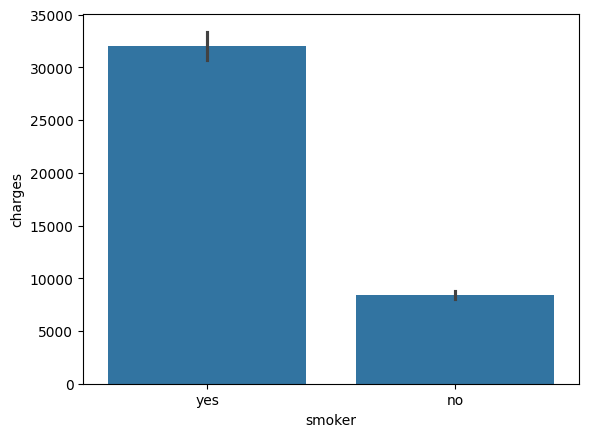

In [50]:
sns.barplot(data=medical_df,x='smoker',y="charges")

In [52]:
smoker_code={'no':0,'yes':1}

In [53]:
medical_df['smoker_code']=medical_df.smoker.map(smoker_code)

In [54]:
medical_df

,age,sex,bmi,children,smoker,region,charges,smoker_code
0,19,female,27.900,0,yes,southwest,16884.92400,1
1,18,male,33.770,1,no,southeast,1725.55230,0
2,28,male,33.000,3,no,southeast,4449.46200,0
3,33,male,22.705,0,no,northwest,21984.47061,0
4,32,male,28.880,0,no,northwest,3866.85520,0
...,...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830,0
1334,18,female,31.920,0,no,northeast,2205.98080,0
1335,18,female,36.850,0,no,southeast,1629.83350,0
1336,21,female,25.800,0,no,southwest,2007.94500,0


In [55]:
medical_df.charges.corr(medical_df.smoker_code)

np.float64(0.787251430498478)

In [80]:
features =["age","bmi","sex_code","smoker_code","children"]

In [81]:
x=medical_df[features]
y=medical_df["charges"]

In [82]:
model.fit(x,y)

LinearRegression()

In [83]:
predictions=model.predict(x)

In [84]:
y

,charges
0,16884.92400
1,1725.55230
2,4449.46200
3,21984.47061
4,3866.85520
...,...
1333,10600.54830
1334,2205.98080
1335,1629.83350
1336,2007.94500


In [85]:
root_mean_squared_error(y,predictions)

6056.100708754546

In [71]:
sex_code={'female':0,'male':1}
medical_df['sex_code']=medical_df['sex'].map(sex_code)


In [72]:
medical_df

,age,sex,bmi,children,smoker,region,charges,smoker_code,sex_code
0,19,female,27.900,0,yes,southwest,16884.92400,1,0
1,18,male,33.770,1,no,southeast,1725.55230,0,1
2,28,male,33.000,3,no,southeast,4449.46200,0,1
3,33,male,22.705,0,no,northwest,21984.47061,0,1
4,32,male,28.880,0,no,northwest,3866.85520,0,1
...,...,...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830,0,1
1334,18,female,31.920,0,no,northeast,2205.98080,0,0
1335,18,female,36.850,0,no,southeast,1629.83350,0,0
1336,21,female,25.800,0,no,southwest,2007.94500,0,0


In [73]:
medical_df.charges.corr(medical_df.sex_code)

np.float64(0.057292062202025484)

In [88]:
enc =OneHotEncoder()

In [94]:
enc.fit_transform(medical_df[["region"]])

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 1338 stored elements and shape (1338, 4)>

In [92]:
medical_df

,age,sex,bmi,children,smoker,region,charges,smoker_code,sex_code
0,19,female,27.900,0,yes,southwest,16884.92400,1,0
1,18,male,33.770,1,no,southeast,1725.55230,0,1
2,28,male,33.000,3,no,southeast,4449.46200,0,1
3,33,male,22.705,0,no,northwest,21984.47061,0,1
4,32,male,28.880,0,no,northwest,3866.85520,0,1
...,...,...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830,0,1
1334,18,female,31.920,0,no,northeast,2205.98080,0,0
1335,18,female,36.850,0,no,southeast,1629.83350,0,0
1336,21,female,25.800,0,no,southwest,2007.94500,0,0


In [96]:
numeric_cols =['age','bmi','children']

In [97]:
scaler=StandardScaler()

In [98]:
scaler.fit(medical_df[numeric_cols])

StandardScaler()

In [99]:
scaled_inputs =scaler.transform(medical_df[numeric_cols])

In [101]:
scaled_inputs

array([[-1.43876426, -0.45332   , -0.90861367],
       [-1.50996545,  0.5096211 , -0.07876719],
       [-0.79795355,  0.38330685,  1.58092576],
       ...,
       [-1.50996545,  1.0148781 , -0.90861367],
       [-1.29636188, -0.79781341, -0.90861367],
       [ 1.55168573, -0.26138796, -0.90861367]])

In [102]:
medical_df.head()

,age,sex,bmi,children,smoker,region,charges,smoker_code,sex_code
0,19,female,27.900,0,yes,southwest,16884.92400,1,0
1,18,male,33.770,1,no,southeast,1725.55230,0,1
2,28,male,33.000,3,no,southeast,4449.46200,0,1
3,33,male,22.705,0,no,northwest,21984.47061,0,1
4,32,male,28.880,0,no,northwest,3866.85520,0,1


In [104]:
cat_cols=["sex_code","smoker_code"]

In [105]:
cat_data =medical_df[cat_cols].values

In [107]:
inputs =np.concatenate((scaled_inputs,cat_data),axis=1)
target =medical_df["charges"]

In [108]:
model.fit(inputs,target)

LinearRegression()

In [110]:
predictions =model.predict(inputs)

In [111]:
root_mean_squared_error(target,predictions)

6056.100708754546